## Notebook for data examination after clustering

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
import os

from tqdm import tqdm

import hdbscan

from scipy.spatial.distance import cdist

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score, silhouette_score#, calinski_harabasz_score, davies_bouldin_score

from sklearn.manifold import TSNE

from sklearn.cluster import DBSCAN
from sklearn.cluster import SpectralClustering
from sklearn.cluster import AgglomerativeClustering

import plotly.express as px
import plotly.graph_objects as go

In [2]:
# import the merged data file
merged_df = pd.read_csv('fusion_results_merged_with_clusters.csv.gzip', compression='gzip', sep=',', header=0, dtype={'# sample': str, 'Depth': str})
merged_df.head()

,Mg,Al,Si,K,Ca,Ti,Mn,Fe,Rb,Sr,...,Mn mole fraction,Fe mole fraction,Rb mole fraction,Sr mole fraction,Zr mole fraction,Ba mole fraction,La mole fraction,Ce mole fraction,U mole fraction,Agglomerative Cluster
0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,2397.7219,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,4
1,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,7130.3062,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,4
2,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,41294.3340,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,4
3,0.0,0.0,0.0,0.0,0.0,3783.7901,0.0,0.0000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.014665,0.043513,0.0,7
4,0.0,0.0,0.0,0.0,0.0,0.0000,0.0,2540.5517,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,4


In [3]:
# Calculate the mean and standard deviation for each cluster
def calculate_cluster_stats(dataframe, cluster_col=['Agglomerative Cluster']):
    numeric_df = dataframe.select_dtypes(include='number').copy()
    numeric_df[cluster_col[0]] = dataframe[cluster_col[0]].values
    stats = numeric_df.groupby(cluster_col).agg(['mean', 'std'])
    return stats

# Compute stats for clusters and for samples
cluster_stats = calculate_cluster_stats(merged_df, cluster_col=['Agglomerative Cluster'])
sample_stats = calculate_cluster_stats(merged_df, cluster_col=['# sample'])

# Compute cluster sizes
size_clusters = merged_df['Agglomerative Cluster'].value_counts()
size_clusters.sort_index(inplace=True)

size_clusters_df = pd.DataFrame(size_clusters).reset_index()
size_clusters_df.columns = ['Agglomerative Cluster', 'Number']
size_clusters_df['Fraction'] = size_clusters_df['Number'] / size_clusters_df['Number'].sum() * 100

# Compute total mass per cluster and merge it
total_mass = merged_df.groupby('Agglomerative Cluster')['Sum'].sum().reset_index()
size_clusters_df = pd.merge(size_clusters_df, total_mass, on='Agglomerative Cluster')
size_clusters_df.rename(columns={'Sum': 'Total mass'}, inplace=True)

# Create a sentence column for plotting or reporting
size_clusters_df['Sentence'] = size_clusters_df.apply(
    lambda row: f"Cluster {int(row['Agglomerative Cluster'])}\nn = {int(row['Number'])}\n({row['Fraction']:.1f}%)",
    axis=1
)

# Preview the result
size_clusters_df.head()

,Agglomerative Cluster,Number,Fraction,Total mass,Sentence
0,0,14637,3.056475,2.114683e+09,Cluster 0\nn = 14637\n(3.1%)
1,1,45943,9.593744,6.415827e+08,Cluster 1\nn = 45943\n(9.6%)
2,2,98779,20.626873,6.457519e+09,Cluster 2\nn = 98779\n(20.6%)
3,3,8972,1.873519,1.128816e+08,Cluster 3\nn = 8972\n(1.9%)
4,4,232445,48.538793,1.322904e+09,Cluster 4\nn = 232445\n(48.5%)


In [4]:
# read the elements.txt file to save the elements
df_elements = pd.read_csv('elements.txt', sep='\t', header=None, names=['Element'])
# Convert the elements DataFrame to a list
elements = df_elements['Element'].tolist()

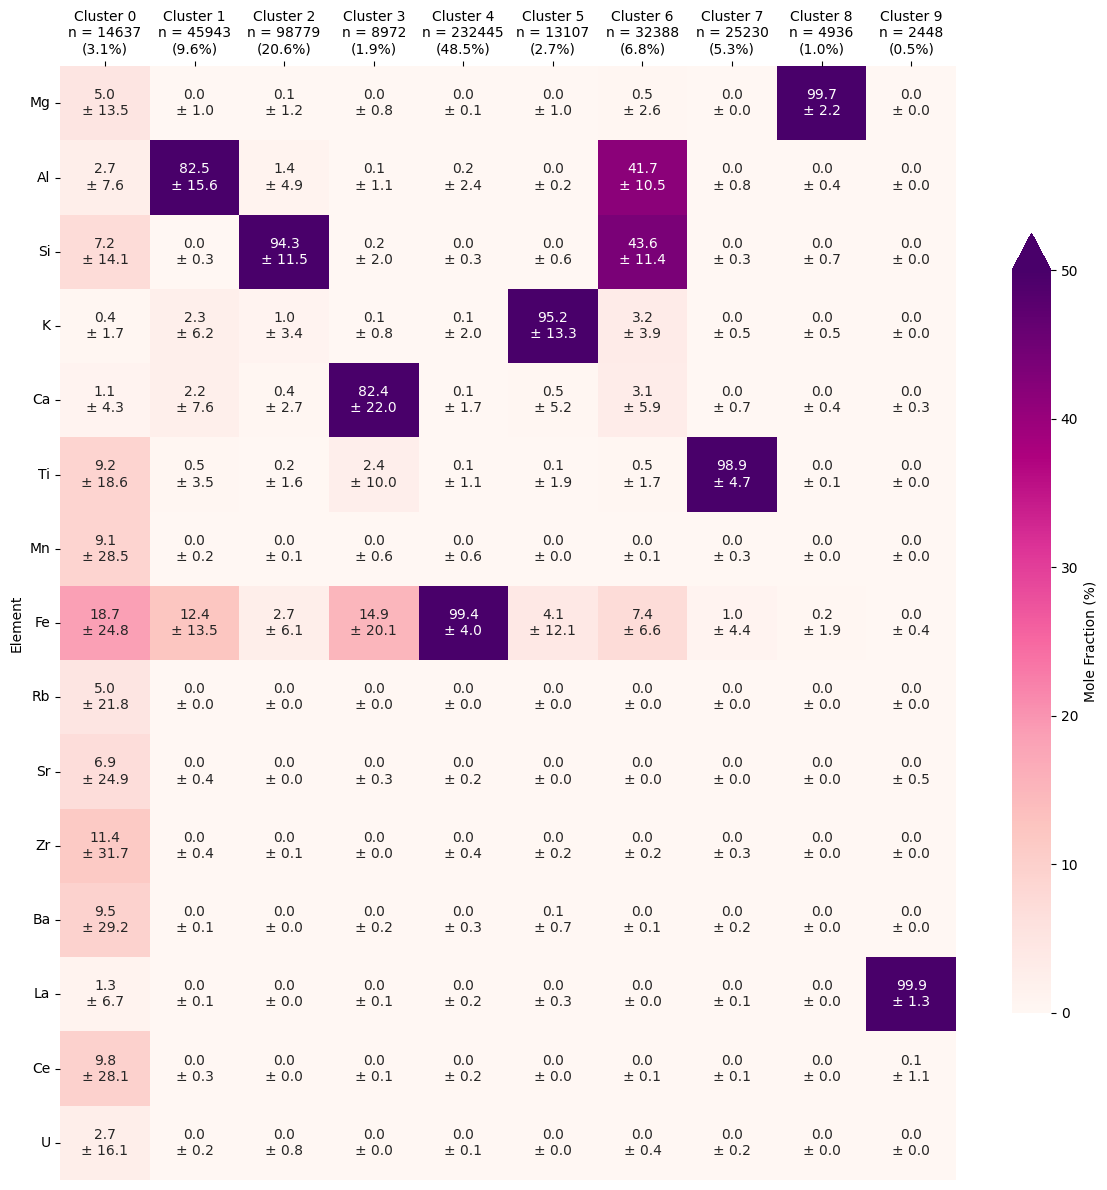

In [5]:
# Select column "mass fraction"
mole_fraction_cols = [col for col in cluster_stats.columns if col[0].endswith('mole fraction')]

# Extract mean & std
means = cluster_stats[mole_fraction_cols].xs('mean', axis=1, level=1) * 100
stds = cluster_stats[mole_fraction_cols].xs('std', axis=1, level=1) * 100

# Creat an annotation matrice
annot = means.round(1).astype(str) + "\n± " + stds.round(1).astype(str)

# Plot heatmap
plt.figure(figsize=(12, 12))
ax = sns.heatmap(
    means.T,
    annot=annot.T,
    fmt="",
    cmap='RdPu', vmin=0, vmax=50,
    cbar_kws={'label': 'Mole Fraction (%)', "shrink": 0.7, 'extend': 'max', 'extendrect': False},
    xticklabels=size_clusters_df['Sentence'], yticklabels=elements
)

plt.yticks(rotation=0)
plt.xticks(rotation=0)
ax.xaxis.tick_top()
plt.ylabel('Element')
plt.xlabel('')
plt.tight_layout()
plt.savefig("cluster_compo_moles.png", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/zk/2_bksjhn0g731cln_7qgt3q00000gn/T/ipykernel_31654/1037635794.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('plasma', stacked_df.shape[1])  # choose a colormap with enough distinct colors


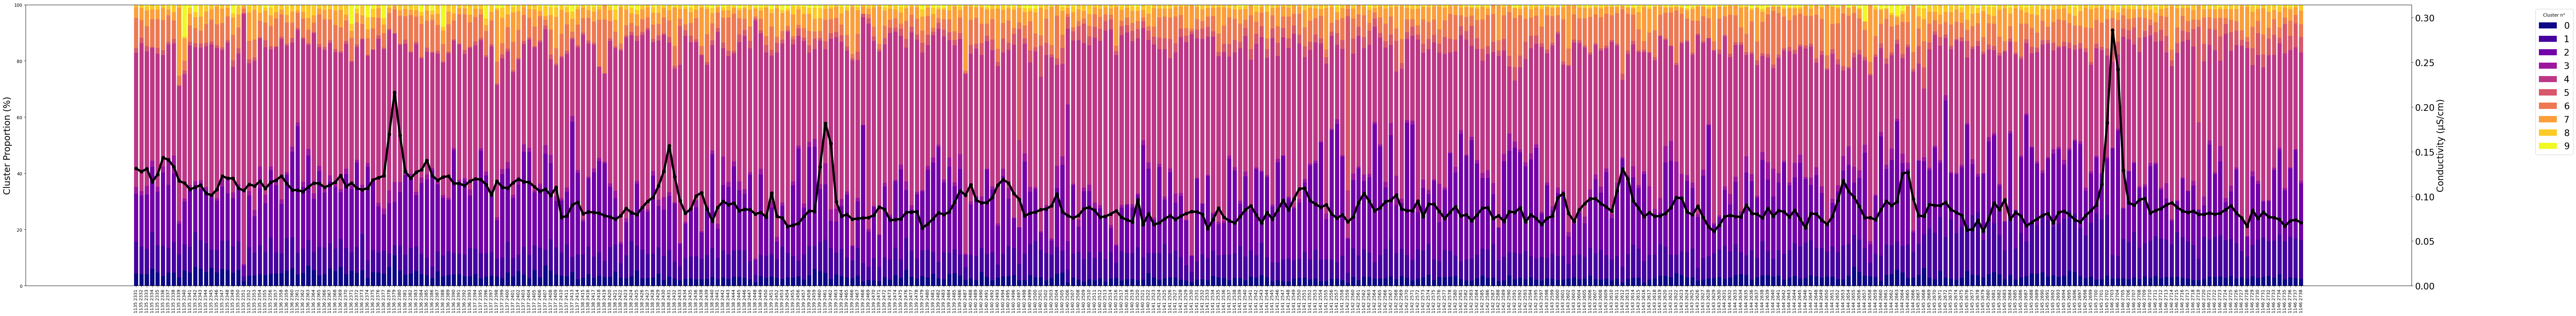

In [6]:
# Calculate the proportion of each cluster per sample
count_df = merged_df.groupby(['Filename', 'Agglomerative Cluster']).size().reset_index(name='Count')

# Calculate the total number of clusters per sample
total_df = merged_df.groupby('Filename').size().reset_index(name='Total')

# Merge the two DataFrames to get the proportion
proportion_df = pd.merge(count_df, total_df, on='Filename')
proportion_df['Proportion'] = 100 * proportion_df['Count'] / proportion_df['Total']

# Prepare the data (pivot so each cluster becomes a column)
stacked_df = proportion_df.pivot(index='Filename', columns='Agglomerative Cluster', values='Proportion').fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(80, 10))

bottom = None  # to stack bars on top of each other
colors = plt.cm.get_cmap('plasma', stacked_df.shape[1])  # choose a colormap with enough distinct colors

for i, cluster in enumerate(stacked_df.columns):
    ax.bar(
        stacked_df.index,
        stacked_df[cluster],
        bottom=bottom,
        label=cluster,
        color=colors(i)
    )
    # Update bottom for next cluster
    bottom = stacked_df[cluster] if bottom is None else bottom + stacked_df[cluster]

# Formatting
ax.set_ylabel("Cluster Proportion (%)", fontsize=20)
ax.set_xticks(range(len(stacked_df.index)))
ax.set_xticklabels(stacked_df.index, rotation=90)
ax.legend(title="Cluster n°", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20)

# add a twin y-axis for the conductivity
ax2 = ax.twinx()
# Compute mean conductivity per sample
cond_df = merged_df.groupby('Filename')['Conductivity'].mean().reindex(stacked_df.index)

# Plot conductivity per sample
ax2.plot(
    cond_df.index,
    cond_df.values,
    color='black',
    marker='o',
    label='Conductivity (µS/cm)',
    markersize=7,
    linewidth=5
)
# Set the y-axis label for conductivity
ax2.set_ylabel('Conductivity (µS/cm)', fontsize=20)
# Set the y-axis limits for conductivity
ax2.set_ylim(0, merged_df['Conductivity'].max() * 1.1)

# # Increase y-ticks fontsize
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.tight_layout()
plt.savefig("cluster_proportions.png", dpi=300, bbox_inches='tight')
plt.show()